# Softmax experiment
## Attention_nu_int_dim_20260422.ipynb
## consider a range of alphas. Generate W with tail exponent alpha
## calculate PP(W)
## attnW = softmax(W / sqrt(d))
## calculate PP(attnW)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd

In [2]:
import PatnaikPearson as pp
import cupy

In [3]:
# combine these sets
arr1 = np.arange(0.05, 0.3, 0.01)
arr2 = np.arange(0.3, 0.7, 0.02)
arr3 = np.arange(0.7, 1.0, 0.03)
arr4 = np.arange(1.0, 2.0, 0.05)
arr5 = np.arange(2.0, 5.1, 0.1)
combined = np.unique(np.concatenate((arr1, arr2)))
combined = np.unique(np.concatenate((combined, arr3)))
combined = np.unique(np.concatenate((combined, arr4)))
combined = np.unique(np.concatenate((combined, arr5)))

In [4]:
print(len(combined))

107


In [5]:
these_alphas = combined #np.arange(0.05,2.05,0.05)
num_values = len(these_alphas)

alpha_vals = np.zeros(num_values)
implied_alpha_W_vals = np.zeros(num_values)
implied_alpha_softmaxW = np.zeros(num_values)
actual_nu_W_over_d_vals = np.zeros(num_values)
actual_alpha_softmaxW_vals = np.zeros(num_values)
estimated_alpha_softmaxW_vals = np.zeros(num_values)
actual_nu_softmaxW_over_d_vals = np.zeros(num_values)
implied_nu_softmaxW_over_d_vals = np.zeros(num_values)

d = 1000

i = 0
for this_alpha in these_alphas: # in range(5):

  #this_alpha = 1.0 + (0.5 * i)
  #this_alpha = 0.5 + (0.01 * i)
  alpha_vals[i] = this_alpha

  W = pp.generate_square_weight_matrix(d, this_alpha)

  actual_nu_W_over_d = pp.calculate_PatnaikPearson_dim(W) / d
  actual_nu_W_over_d_vals[i] = actual_nu_W_over_d

  implied_alpha_W = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_W_over_d, d)
  implied_alpha_W_vals[i] = implied_alpha_W

  softmaxW = pp.row_wise_softmax(W / math.sqrt(d))

  actual_nu_softmaxW_over_d = pp.calculate_PatnaikPearson_dim(softmaxW) / d
  actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d

  actual_alpha_softmaxW = pp.calculate_alpha_given_nu_over_d_and_d(actual_nu_softmaxW_over_d, d)
  actual_alpha_softmaxW_vals[i] = actual_alpha_softmaxW

  estimated_alpha_softmaxW = pp.calculate_softmax_alpha(implied_alpha_W)
  estimated_alpha_softmaxW_vals[i] = estimated_alpha_softmaxW

  implied_nu_softmaxW_over_d = pp.calculate_nu_over_d_given_alpha_and_d(estimated_alpha_softmaxW, d)
  implied_nu_softmaxW_over_d_vals[i] = implied_nu_softmaxW_over_d

  print(i, "this_alpha = ", this_alpha)
  print(i, "implied_alpha_W = ", implied_alpha_W)
  print(i, "actual_alpha_softmaxW = ", actual_alpha_softmaxW)
  print(i, "estimated_alpha_softmaxW = ", estimated_alpha_softmaxW)
  print(i, "actual_nu_softmaxW_over_d = ", actual_nu_softmaxW_over_d)
  print(i, "implied_nu_softmaxW_over_d = ", implied_nu_softmaxW_over_d)

  #print(i, this_alpha, implied_alpha_W,  actual_alpha_softmaxW, estimated_alpha_softmaxW, actual_nu_softmaxW_over_d, implied_nu_softmaxW_over_d)
  i +=1

 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
0 this_alpha =  0.05
0 implied_alpha_W =  0.29289330978016354
0 actual_alpha_softmaxW =  0.29289330978016015
0 estimated_alpha_softmaxW =  0.29335014557765837
0 actual_nu_softmaxW_over_d =  0.001000000000000006
0 implied_nu_softmaxW_over_d =  0.0010025871566752738
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha : need to re-do hardcoded values ** 
** get_alpha_vals_softmax_alpha_vals : need to recalculate for new alpha **
1 this_alpha =  0.060000000000000005
1 implied_alpha_W =  0.29294386452721843
1 actual_alpha_softmaxW =  0.2928933097801593
1 estimated_alpha_softmaxW =  0.29961194170858774
1 actual_nu_softmaxW_over_d =  0.0010000000000000018
1 implied_nu_softmaxW_over_d =  0.0010385552745521488
 ** generate_square_weight_matrix: using GPU **
 ** calculate_softmax_alpha 

In [ ]:
xx = [1,2.5,3]
print(xx)
print(np.array(xx) - 1.0)

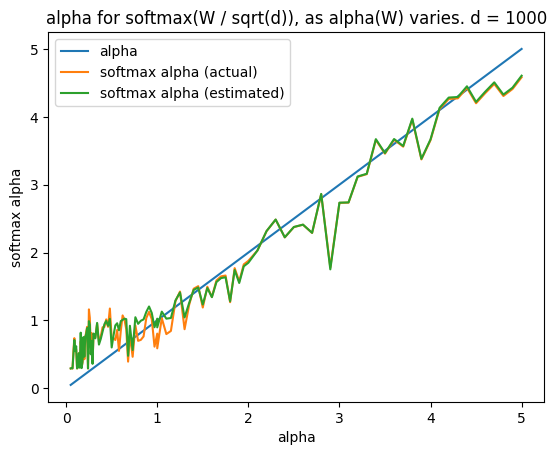

In [6]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)

plt.plot(alpha_vals, alpha_vals, label = "alpha")
plt.plot(alpha_vals, actual_alpha_softmaxW_vals, label = "softmax alpha (actual)")
plt.plot(alpha_vals, estimated_alpha_softmaxW_vals, label = "softmax alpha (estimated)")
plt.xlabel("alpha")
plt.ylabel("softmax alpha")
plt.title(this_title)
plt.legend()
plt.show()

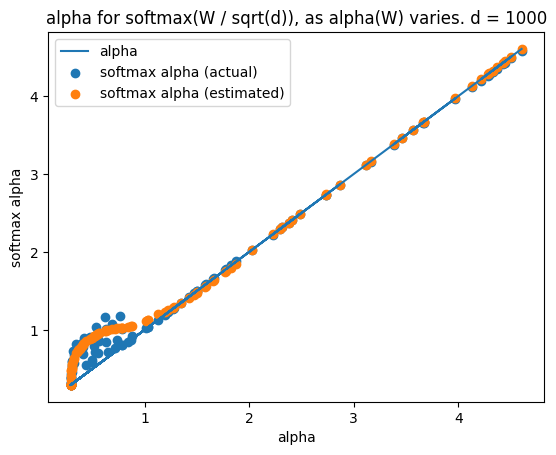

In [8]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)

plt.plot(implied_alpha_W_vals, implied_alpha_W_vals, label = "alpha")
plt.scatter(implied_alpha_W_vals, actual_alpha_softmaxW_vals, label = "softmax alpha (actual)")
plt.scatter(implied_alpha_W_vals, estimated_alpha_softmaxW_vals, label = "softmax alpha (estimated)")
plt.xlabel("alpha")
plt.ylabel("softmax alpha")
plt.title(this_title)
plt.legend()
plt.savefig('pp_softmax_one.pdf', dpi=300, bbox_inches='tight')
plt.show()

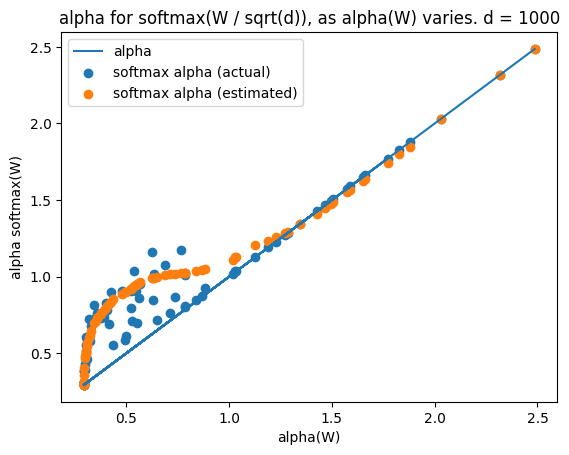

In [17]:
this_title = "alpha for softmax(W / sqrt(d)), as alpha(W) varies. d = " + str(d)
k = 80
plt.plot(implied_alpha_W_vals[0:k], implied_alpha_W_vals[0:k], label = "alpha")
#plt.plot(implied_alpha_W_vals[0:k], implied_alpha_W_vals[0:k], label = "implied alpha")
#plt.plot(alpha_vals[0:k], softmax_alpha_vals[0:k], label = "softmax alpha")
plt.scatter(implied_alpha_W_vals[0:k], actual_alpha_softmaxW_vals[0:k], label = "softmax alpha (actual)")
plt.scatter(implied_alpha_W_vals[0:k], estimated_alpha_softmaxW_vals[0:k], label = "softmax alpha (estimated)")
plt.xlabel("alpha(W)")
plt.ylabel("alpha softmax(W)")
plt.title(this_title)
plt.legend()
plt.savefig('pp_softmax_two.pdf', dpi=300, bbox_inches='tight')
plt.show()

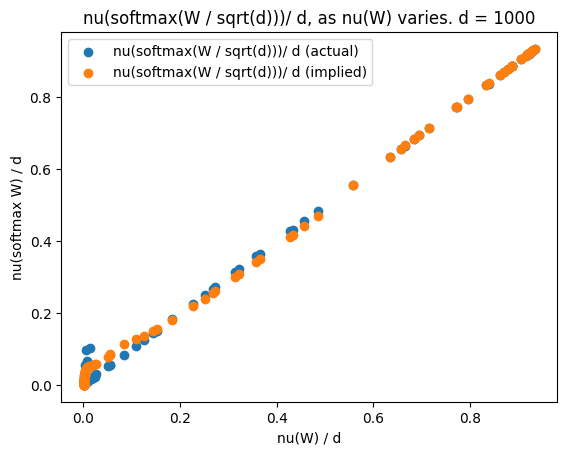

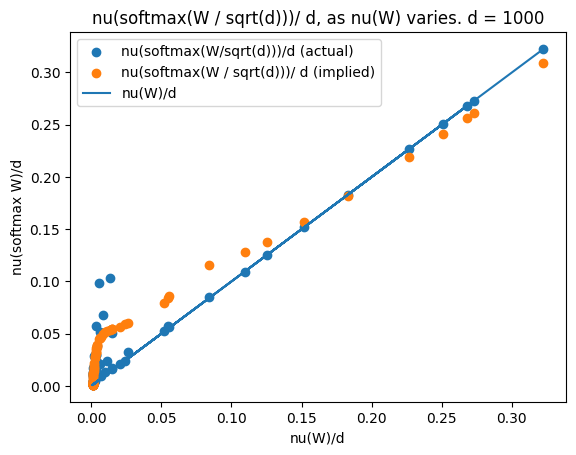

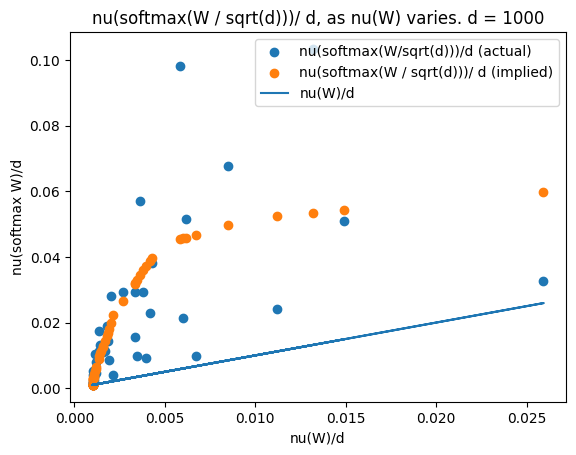

In [16]:
np_actual_nu_W_over_d_vals = np.zeros(len(actual_nu_W_over_d_vals))
for i in range(len(actual_nu_W_over_d_vals)):
    np_actual_nu_W_over_d_vals[i] = actual_nu_W_over_d_vals[i]

np_actual_nu_softmaxW_over_d_vals = np.zeros(len(actual_nu_softmaxW_over_d_vals))
for i in range(len(actual_nu_softmaxW_over_d_vals)):
    np_actual_nu_softmaxW_over_d_vals[i] = actual_nu_softmaxW_over_d_vals[i]
    
this_title = "nu(softmax(W / sqrt(d)))/ d, as nu(W) varies. d = " + str(d)
plt.scatter(np_actual_nu_W_over_d_vals, np_actual_nu_softmaxW_over_d_vals, label = "nu(softmax(W / sqrt(d)))/ d (actual)")
plt.scatter(np_actual_nu_W_over_d_vals, implied_nu_softmaxW_over_d_vals, label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.xlabel("nu(W) / d")
plt.ylabel("nu(softmax W) / d")
plt.legend()
plt.title(this_title)
plt.show()

k = 70
plt.scatter(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W/sqrt(d)))/d (actual)")
#plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.scatter(np_actual_nu_W_over_d_vals[0:k], implied_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.plot(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.xlabel("nu(W)/d")
plt.ylabel("nu(softmax W)/d")
plt.legend()
plt.title(this_title)
plt.show()

k = 50
plt.scatter(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W/sqrt(d)))/d (actual)")
#plt.plot(actual_nu_W_over_d_vals[0:k], actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.scatter(np_actual_nu_W_over_d_vals[0:k], implied_nu_softmaxW_over_d_vals[0:k], label = "nu(softmax(W / sqrt(d)))/ d (implied)")
plt.plot(np_actual_nu_W_over_d_vals[0:k], np_actual_nu_W_over_d_vals[0:k], label="nu(W)/d")
plt.xlabel("nu(W)/d")
plt.ylabel("nu(softmax W)/d")
plt.legend()
plt.title(this_title)
plt.show()

In [8]:
print("alpha_vals = ", alpha_vals[0:100])
print()
#print("softmax_alpha_vals = ", softmax_alpha_vals[0:100])
print("actual_alpha_softmaxW_vals = ", actual_alpha_softmaxW_vals[0:100])
print()

alpha_vals =  [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7
 0.75 0.8  0.85 0.9  0.95 1.   1.05 1.1  1.15 1.2  1.25 1.3  1.35 1.4
 1.45 1.5  1.55 1.6  1.65 1.7  1.75 1.8  1.85 1.9  1.95 2.  ]

actual_alpha_softmaxW_vals =  [0.29289331 0.32890154 0.29289331 0.81549877 0.90404504 0.75420037
 0.8248744  0.43024685 0.83066982 0.88619606 0.68999312 0.84726499
 0.62116191 0.70039069 0.84906522 0.86621445 0.89716727 0.81850722
 1.1627362  0.57429378 1.25790612 0.95706016 0.94892476 0.9792722
 0.80761907 1.07435505 0.85657227 1.68166595 1.27040743 1.39326608
 1.23147814 1.63491828 1.74656859 1.62357868 1.98389327 1.42671731
 1.6452051  2.05012506 1.911005   2.08899048]

